# 🤗 Using Pretrained Vision Transformers

This notebook demonstrates how to use pretrained Vision Transformers from popular libraries and repositories.

---

## 📚 **Learning Objectives**
- Use pretrained ViT models from timm library
- Fine-tune pretrained models for custom tasks
- Explore different ViT architectures and variants
- Understand transfer learning with ViTs
- Discover community implementations and resources

## 🛠️ **1. Setting Up the Environment**

In [ ]:
# Install required packages
# !pip install timm torch torchvision matplotlib pillow

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Timm version: {timm.__version__}")

🔧 Using device: cuda
PyTorch version: 2.10.0+cu128
Timm version: 1.0.26


## 🌟 **2. Exploring Available Pretrained Models**

The `timm` library provides a comprehensive collection of pretrained Vision Transformer models.

In [ ]:
# List available ViT models in timm
vit_models = timm.list_models('vit*', pretrained=True)
print(f"📊 Available Pretrained ViT Models ({len(vit_models)} total):")
print("=" * 60)

# Show first 10 models with details
for i, model_name in enumerate(vit_models[:10]):
    print(f"{i+1:2d}. {model_name}")

if len(vit_models) > 10:
    print(f"... and {len(vit_models) - 10} more models")

📊 Available Pretrained ViT Models (338 total):
 1. vit_7b_patch16_dinov3.lvd1689m
 2. vit_7b_patch16_dinov3.sat493m
 3. vit_base_mci_224.apple_mclip
 4. vit_base_mci_224.apple_mclip2_dfndr2b
 5. vit_base_mci_224.apple_mclip_lt
 6. vit_base_patch8_224.augreg2_in21k_ft_in1k
 7. vit_base_patch8_224.augreg_in21k
 8. vit_base_patch8_224.augreg_in21k_ft_in1k
 9. vit_base_patch8_224.dino
10. vit_base_patch14_dinov2.lvd142m
... and 328 more models


## 🔍 **3. Loading and Examining Pretrained Models**

In [ ]:
# Load a pretrained ViT model
model_name = 'vit_base_patch16_224'
model = timm.create_model(model_name, pretrained=True)
model.eval()

print(f"🤖 Loaded Model: {model_name}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model size: ~{sum(p.numel() for p in model.parameters()) * 4 / 1024**2:.1f} MB")

# Get model configuration
model_config = model.default_cfg
print(f"\n📋 Model Configuration:")
for key, value in model_config.items():
    print(f"  {key}: {value}")

# Model architecture summary
print(f"\n🏗️ Architecture Overview:")
print(f"Input size: {model_config['input_size']}")
print(f"Number of classes: {model.num_classes}")
print(f"Patch size: {model.patch_embed.patch_size}")
print(f"Embedding dimension: {model.embed_dim}")
print(f"Number of layers: {len(model.blocks)}")
print(f"Number of attention heads: {model.blocks[0].attn.num_heads}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

🤖 Loaded Model: vit_base_patch16_224
Number of parameters: 86,567,656
Model size: ~330.2 MB

📋 Model Configuration:
  url: 
  hf_hub_id: timm/vit_base_patch16_224.augreg2_in21k_ft_in1k
  architecture: vit_base_patch16_224
  tag: augreg2_in21k_ft_in1k
  custom_load: False
  input_size: (3, 224, 224)
  fixed_input_size: True
  interpolation: bicubic
  crop_pct: 0.9
  crop_mode: center
  mean: (0.5, 0.5, 0.5)
  std: (0.5, 0.5, 0.5)
  num_classes: 1000
  pool_size: None
  first_conv: patch_embed.proj
  classifier: head
  license: apache-2.0

🏗️ Architecture Overview:
Input size: (3, 224, 224)
Number of classes: 1000
Patch size: (16, 16)
Embedding dimension: 768
Number of layers: 12
Number of attention heads: 12


## 🎯 **4. Using Pretrained Models for Inference**

In [4]:
# Load ImageNet class labels
def load_imagenet_labels():
    """Load ImageNet class labels."""
    import urllib.request
    import json

    try:
        url = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'
        urllib.request.urlretrieve(url, 'imagenet_classes.txt')
        with open('imagenet_classes.txt', 'r') as f:
            classes = [line.strip() for line in f.readlines()]
        return classes
    except:
        print("Could not download ImageNet labels. Using dummy labels.")
        return [f"class_{i}" for i in range(1000)]

imagenet_classes = load_imagenet_labels()
print(f"📊 Loaded {len(imagenet_classes)} ImageNet class labels")

# Define preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

def predict_image(model, image_tensor, top_k=5):
    """Make prediction on a single image."""
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

        # Get top-k predictions
        top_prob, top_catid = torch.topk(probabilities, top_k)

        results = []
        for i in range(top_k):
            results.append({
                'class': imagenet_classes[top_catid[i]],
                'probability': top_prob[i].item()
            })

        return results

print("🎯 Inference functions ready!")

📊 Loaded 1000 ImageNet class labels
🎯 Inference functions ready!


100%|██████████| 170M/170M [01:52<00:00, 1.52MB/s]


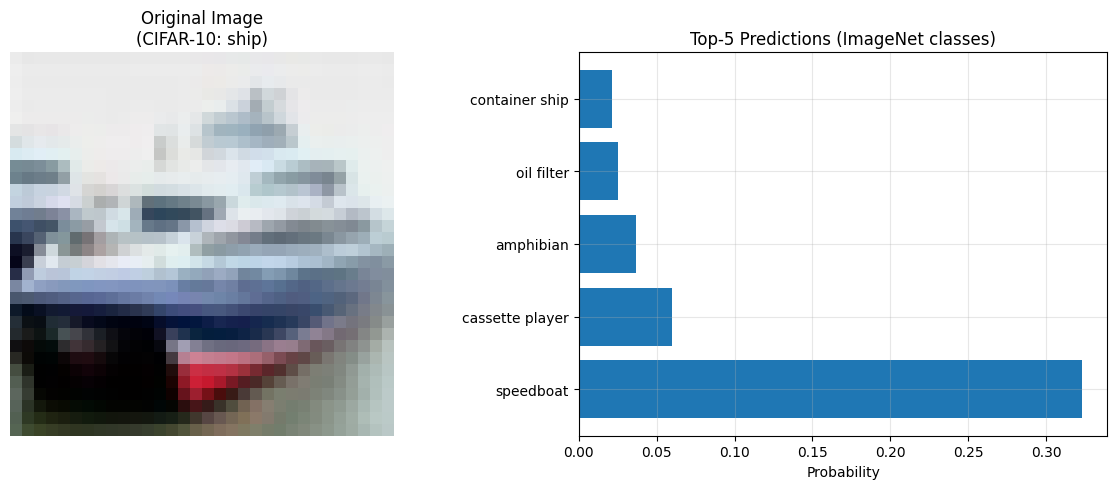

🎯 Prediction Results:
1. speedboat: 0.323
2. cassette player: 0.060
3. amphibian: 0.037
4. oil filter: 0.025
5. container ship: 0.021


In [5]:
# Test with CIFAR-10 sample (as a demo)
# Load a sample image
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
sample_image, true_label = testset[1]

# Convert PIL to tensor and preprocess
input_tensor = preprocess(sample_image)

# Make prediction
predictions = predict_image(model, input_tensor)

# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Show original image
ax1.imshow(sample_image)
ax1.set_title(f'Original Image\n(CIFAR-10: {testset.classes[true_label]})')
ax1.axis('off')

# Show predictions
classes = [pred['class'] for pred in predictions]
probs = [pred['probability'] for pred in predictions]

ax2.barh(range(len(classes)), probs)
ax2.set_yticks(range(len(classes)))
ax2.set_yticklabels([f"{cls[:20]}..." if len(cls) > 20 else cls for cls in classes])
ax2.set_xlabel('Probability')
ax2.set_title('Top-5 Predictions (ImageNet classes)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 Prediction Results:")
for i, pred in enumerate(predictions):
    print(f"{i+1}. {pred['class']}: {pred['probability']:.3f}")

## 🔧 **5. Fine-tuning Pretrained Models**

Let's fine-tune a pretrained ViT for CIFAR-100 classification.

In [6]:
# Load CIFAR-100 dataset
transform_train = transforms.Compose([
    transforms.Resize(224),  # Resize to match pretrained model input
    transforms.RandomCrop(224, padding=28),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                         download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                        download=True, transform=transform_test)

# Use smaller batch size for fine-tuning
batch_size = 16
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"📊 CIFAR-100 Dataset Loaded:")
print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")
print(f"Number of classes: 100")
print(f"Batch size: {batch_size}")

100%|██████████| 169M/169M [04:25<00:00, 636kB/s]


📊 CIFAR-100 Dataset Loaded:
Training samples: 50000
Test samples: 10000
Number of classes: 100
Batch size: 16


In [7]:
# Create model for fine-tuning
model_ft = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=100)
model_ft = model_ft.to(device)

print(f"🔧 Fine-tuning Setup:")
print(f"Base model: vit_small_patch16_224")
print(f"Pretrained: Yes (ImageNet)")
print(f"Target classes: 100 (CIFAR-100)")
print(f"Parameters: {sum(p.numel() for p in model_ft.parameters()):,}")

# Setup for fine-tuning with different learning rates
# Lower learning rate for pretrained features
backbone_params = []
head_params = []

for name, param in model_ft.named_parameters():
    if 'head' in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},  # Lower LR for pretrained weights
    {'params': head_params, 'lr': 1e-3}       # Higher LR for new head
], weight_decay=0.01)

criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(f"\n⚙️ Training Configuration:")
print(f"Backbone LR: 1e-5")
print(f"Head LR: 1e-3")
print(f"Weight decay: 0.01")
print(f"Scheduler: CosineAnnealingLR")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

🔧 Fine-tuning Setup:
Base model: vit_small_patch16_224
Pretrained: Yes (ImageNet)
Target classes: 100 (CIFAR-100)
Parameters: 21,704,164

⚙️ Training Configuration:
Backbone LR: 1e-5
Head LR: 1e-3
Weight decay: 0.01
Scheduler: CosineAnnealingLR


In [8]:
# Quick fine-tuning demo (few epochs)
def train_epoch_ft(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, targets) in enumerate(dataloader):
        if batch_idx >= 100:  # Limit to 100 batches for demo
            break

        data, targets = data.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        if batch_idx % 25 == 0:
            print(f'Batch {batch_idx:3d}: Loss: {loss.item():.3f}, '
                  f'Acc: {100.*correct/total:.2f}%')

    return running_loss / min(100, len(dataloader)), 100. * correct / total

# Run a few epochs of fine-tuning
print("🏃‍♂️ Starting fine-tuning demo (limited batches)...")
num_epochs_demo = 2

for epoch in range(num_epochs_demo):
    print(f"\n📊 Epoch {epoch + 1}/{num_epochs_demo}:")
    train_loss, train_acc = train_epoch_ft(model_ft, trainloader, criterion, optimizer, device)
    scheduler.step()

    print(f"Epoch {epoch + 1} Summary: Loss: {train_loss:.4f}, "
          f"Accuracy: {train_acc:.2f}%")

print("\n✅ Fine-tuning demo completed!")
print("💡 For full training, run more epochs with the complete dataset.")

🏃‍♂️ Starting fine-tuning demo (limited batches)...

📊 Epoch 1/2:
Batch   0: Loss: 5.433, Acc: 0.00%
Batch  25: Loss: 3.878, Acc: 8.65%
Batch  50: Loss: 3.329, Acc: 18.26%
Batch  75: Loss: 1.422, Acc: 31.09%
Epoch 1 Summary: Loss: 2.8182, Accuracy: 40.12%

📊 Epoch 2/2:
Batch   0: Loss: 1.078, Acc: 81.25%
Batch  25: Loss: 0.762, Acc: 74.76%
Batch  50: Loss: 0.749, Acc: 78.68%
Batch  75: Loss: 0.417, Acc: 79.03%
Epoch 2 Summary: Loss: 0.7851, Accuracy: 79.69%

✅ Fine-tuning demo completed!
💡 For full training, run more epochs with the complete dataset.


## 🎭 **6. Model Comparison: Different ViT Variants**

In [9]:
# Compare different ViT model sizes
model_variants = [
    'vit_tiny_patch16_224',
    'vit_small_patch16_224',
    'vit_base_patch16_224',
    'deit_small_patch16_224'
]

comparison_data = []

for model_name in model_variants:
    try:
        model = timm.create_model(model_name, pretrained=True)

        # Count parameters
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        # Get model info
        config = model.default_cfg

        comparison_data.append({
            'Model': model_name,
            'Parameters (M)': f"{total_params / 1e6:.1f}",
            'Input Size': str(config['input_size']),
            'Embed Dim': model.embed_dim if hasattr(model, 'embed_dim') else 'N/A',
            'Layers': len(model.blocks) if hasattr(model, 'blocks') else 'N/A',
            'Heads': model.blocks[0].attn.num_heads if hasattr(model, 'blocks') else 'N/A'
        })

        del model  # Free memory

    except Exception as e:
        print(f"Could not load {model_name}: {e}")

# Display comparison table
import pandas as pd
df = pd.DataFrame(comparison_data)

print("🎭 ViT Model Comparison:")
print("=" * 80)
print(df.to_string(index=False))

print(f"\n💡 Key Insights:")
print(f"• Tiny models are suitable for resource-constrained environments")
print(f"• Small models offer good balance of performance and efficiency")
print(f"• Base models are the standard for most applications")
print(f"• DeiT models often include distillation training")

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

🎭 ViT Model Comparison:
                 Model Parameters (M)    Input Size  Embed Dim  Layers  Heads
  vit_tiny_patch16_224            5.7 (3, 224, 224)        192      12      3
 vit_small_patch16_224           22.1 (3, 224, 224)        384      12      6
  vit_base_patch16_224           86.6 (3, 224, 224)        768      12     12
deit_small_patch16_224           22.1 (3, 224, 224)        384      12      6

💡 Key Insights:
• Tiny models are suitable for resource-constrained environments
• Small models offer good balance of performance and efficiency
• Base models are the standard for most applications
• DeiT models often include distillation training


## 🌐 **7. Community Resources and Implementations**

The Vision Transformer ecosystem has many excellent implementations and resources from the community.

### 🚀 **lucidrains/vit-pytorch**

One of the most comprehensive and well-maintained ViT implementations comes from **[lucidrains/vit-pytorch](https://github.com/lucidrains/vit-pytorch)**.

#### **Why this repository is excellent:**

🎯 **Features:**
- **Clean, readable implementations** of various ViT architectures
- **Multiple ViT variants** including:
  - Standard Vision Transformer
  - CrossViT (Cross-Attention Multi-Scale Vision Transformer)
  - CaiT (Class-Attention in Image Transformers)
  - PiT (Pooling-based Vision Transformer)
  - LeViT (A Vision Transformer in ConvNet's Clothing)
  - And many more!

📚 **Educational Value:**
- **Simple, understandable code** perfect for learning
- **Well-documented** with clear parameter explanations
- **Modular design** that's easy to modify and experiment with
- **Up-to-date** with latest research developments

🛠️ **Installation and Basic Usage:**

```bash
pip install vit-pytorch
```

```python
from vit_pytorch import ViT

v = ViT(
    image_size = 256,
    patch_size = 32,
    num_classes = 1000,
    dim = 1024,
    depth = 6,
    heads = 16,
    mlp_dim = 2048,
    dropout = 0.1,
    emb_dropout = 0.1
)

img = torch.randn(1, 3, 256, 256)
preds = v(img)  # (1, 1000)
```

### 🏆 **Other Notable Resources:**

1. **Hugging Face Transformers**
   - `transformers` library with ViT support
   - Pre-trained models and tokenizers
   - Easy fine-tuning pipelines

2. **Papers with Code**
   - Track latest ViT research
   - Benchmark comparisons
   - Code implementations

3. **MMClassification**
   - Part of OpenMMLab ecosystem
   - Production-ready implementations
   - Extensive model zoo

## 🎓 **Summary**

In this notebook, we explored:

### **🏗️ Key Technologies:**
- **timm library** for easy access to pretrained models
- **Model variants** and their trade-offs
- **Fine-tuning strategies** for custom tasks
- **Community resources** and implementations

### **💡 Key Insights:**
- Pretrained ViTs can significantly accelerate development
- Different model sizes suit different use cases
- Fine-tuning requires careful hyperparameter selection
- Community implementations provide valuable learning resources

### **🌟 Notable Resources:**
- **[lucidrains/vit-pytorch](https://github.com/lucidrains/vit-pytorch)**: Clean, educational implementations
- **timm library**: Production-ready pretrained models
- **Hugging Face**: Transformer ecosystem integration

---

## 🔗 **Next Steps**
Ready to dive deeper? Get ready for handson ViT Image Classification Task